In [1]:
import glob
import pandas as pd
import numpy as np
import os
import tqdm
import re
from matplotlib import pyplot as plt
file_pattern="dated_Turb*.csv"

import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [13]:
def load_wind_speed_data(path, train_ratio=0.7, feature_col="Wspd"):
        """
        从CSV文件加载风速数据
        
        Parameters:
        path: 文件夹路径
        train_ratio: 训练集比例
        feature_col: 特征列名
        
        Returns:
        numpy array: 风速数据矩阵 [num_turbines, timesteps]
        """
        data_files = glob.glob(os.path.join(path, file_pattern))
        # 提取Turb后面的数字进行排序
        def extract_turb_num(filename):
            basename = os.path.basename(filename)
            match = re.search(r'Turb(\d+)', basename)
            return int(match.group(1)) if match else float('inf')
        data_files.sort(key=extract_turb_num)
        
        if len(data_files) == 0:
            raise ValueError(f"未找到匹配的数据文件: {os.path.join(path, file_pattern)}")
        
        print(f"找到 {len(data_files)} 个风速数据文件")
        # 读取第一个文件确定数据长度
        sample_df = pd.read_csv(data_files[0])
        total_timesteps = len(sample_df)
        train_split = int(train_ratio * total_timesteps)
        print(f"总时间步数: {total_timesteps}, 训练集时间步数: {train_split}")
        
        # 检查特征列是否存在
        if feature_col not in sample_df.columns:
            print(f"特征列 '{feature_col}' 不存在，可用列: {list(sample_df.columns)}")
            raise ValueError(f"特征列 '{feature_col}' 不存在")
        print("目标特征:", feature_col)
        # 初始化数组
        target_series = np.zeros((len(data_files), train_split))
        
        # 加载数据
        for i, file in enumerate(tqdm.tqdm(data_files, desc="加载数据")):
            try:
                df = pd.read_csv(file)
                df = df.fillna(0)
                
                # 检查数据长度
                if len(df) != total_timesteps:
                    print(f"警告: 文件 {file} 的数据长度不一致")
                    min_length = min(len(df), train_split)
                    target_series[i, :min_length] = df[feature_col].iloc[:min_length].values
                else:
                    target_series[i, :] = df[feature_col].iloc[:train_split].values
            except Exception as e:
                print(f"读取文件 {file} 时出错: {e}")

        print(f"数据加载完成: {target_series.shape}")
        return target_series

In [14]:
def compute_correlation_matrix(data, method="pearson", use_abs=False):
    """
    计算风机间的相关性矩阵
    
    Parameters:
    data: numpy array, 风速数据矩阵 [num_turbines, timesteps]
    method: 相关性计算方法 ('pearson', 'pearson_diff', 'pearson_dir')
    use_abs: 是否使用绝对值相关性
    
    Returns:
    numpy array: 相关性矩阵
    """
    if data is None:
        raise ValueError("无风速数据，无法计算相关性矩阵")
    print(f"正在计算相关性矩阵 (方法: {method})...")
    # 数据质量检查
    print("数据质量检查:")
    zero_variance_turbines = []
    for i in range(data.shape[0]):
        data1 = data[i, :]
        std_val = np.std(data1)
        if std_val == 0:
            print(f"警告: 风机 {i} 的风速数据方差为0 (均值: {np.mean(data1):.2f})")
            zero_variance_turbines.append(i)

    # 计算相关性矩阵
    print(f"原始数据形状: {data.shape}")

    #预处理
    processed_data = data
    if method == "pearson_diff":
        # 计算一阶差分
        processed_data = np.diff(data, axis=1)
        print(f"差分数据形状: {processed_data.shape}")
    elif method == "pearson_dir":
        # 计算风速数据的方向
        def angle_to_vector(angles):
            """将角度转换为单位向量"""
            angles_rad = np.radians(angles)
            x = np.cos(angles_rad)  # 范围[-1, 1]
            y = np.sin(angles_rad)  # 范围[-1, 1]
            return x, y
        processed_data = angle_to_vector(data)
        print(f"方向数据形状: {len(processed_data)}")

    # 计算相关性
    if method == "pearson" or method == "pearson_diff":
        correlation_matrix = np.corrcoef(processed_data)
    elif method == "pearson_dir":
        cos_correlation_matrix = np.corrcoef(processed_data[0])
        sin_correlation_matrix = np.corrcoef(processed_data[1])
        correlation_matrix = (cos_correlation_matrix + sin_correlation_matrix) / 2

    # 处理NaN值
    nan_mask = np.isnan(correlation_matrix)
    if np.any(nan_mask):
        print("发现相关性矩阵中有NaN值，进行处理...")
        correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
        # 重新设置对角线为1
        np.fill_diagonal(correlation_matrix, 1.0)
    
    # 使用绝对值相关性
    if use_abs:
        correlation_matrix = np.abs(correlation_matrix)
        print("使用绝对值相关性")
    
    # 设置对角线为0（用于图构建）
    np.fill_diagonal(correlation_matrix, 0)

    return correlation_matrix
    
def print_correlation_stats(correlation_matrix):
    num_nodes = correlation_matrix.shape[0]
    """打印相关性统计信息"""
    # 获取上三角矩阵的相关性值（排除对角线）
    corr_values = correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]
    
    print("\n=== 相关性统计信息 ===")
    print(f"相关系数范围: [{np.min(corr_values):.3f}, {np.max(corr_values):.3f}]")
    print(f"平均相关系数: {np.mean(corr_values):.3f}")
    print(f"相关系数标准差: {np.std(corr_values):.3f}")
    print(f"中位数相关系数: {np.median(corr_values):.3f}")
    
    # 相关性分布统计
    strong_corr = np.sum(np.abs(corr_values) > 0.7)
    medium_corr = np.sum((np.abs(corr_values) > 0.4) & (np.abs(corr_values) <= 0.7))
    weak_corr = np.sum((np.abs(corr_values) > 0.2) & (np.abs(corr_values) <= 0.4))
    very_weak_corr = np.sum(np.abs(corr_values) <= 0.2)
    
    total_pairs = len(corr_values)
    print(f"\n相关性强度分布:")
    print(f"  强相关 (>0.7): {strong_corr}/{total_pairs} ({strong_corr/total_pairs*100:.1f}%)")
    print(f"  中等相关 (0.4-0.7): {medium_corr}/{total_pairs} ({medium_corr/total_pairs*100:.1f}%)")
    print(f"  弱相关 (0.2-0.4): {weak_corr}/{total_pairs} ({weak_corr/total_pairs*100:.1f}%)")
    print(f"  很弱相关 (≤0.2): {very_weak_corr}/{total_pairs} ({very_weak_corr/total_pairs*100:.1f}%)")
    
    # 不同阈值下的连接统计
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    print(f"\n不同阈值下的连接统计:")
    for thresh in thresholds:
        connections = np.sum(np.abs(correlation_matrix) > thresh) // 2  # 除以2因为对称
        total_possible = num_nodes * (num_nodes - 1) // 2
        ratio = connections / total_possible * 100 if total_possible > 0 else 0
        print(f"  阈值 {thresh:.1f}: {connections}/{total_possible} ({ratio:.1f}%) 连接")

def visualize_correlation_matrix(correlation_matrix, save_path="correlation_matrix.png", figsize=(12, 10)):
    """
    可视化相关性矩阵
    
    Parameters:
    correlation_matrix: 相关性矩阵
    save_path: 保存路径
    figsize: 图像大小
    """
    
    plt.figure(figsize=figsize)
    
    # 创建相关性矩阵的副本用于显示（恢复对角线为1）
    display_matrix = correlation_matrix.copy()
    np.fill_diagonal(display_matrix, 1.0)
    
    # 绘制热力图
    im = plt.imshow(display_matrix, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
    
    plt.colorbar(im, label='相关系数')
    plt.title('风速相关性矩阵')
    plt.xlabel('风机ID')
    plt.ylabel('风机ID')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"相关性矩阵图已保存为 {save_path}")

In [16]:
wind_speed = load_wind_speed_data("/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wspd")
original_wind_direction = load_wind_speed_data("/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wdir")
wind_direction = original_wind_direction % 360

找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wspd


加载数据:   0%|          | 0/134 [00:00<?, ?it/s]

加载数据: 100%|██████████| 134/134 [00:13<00:00,  9.99it/s]


数据加载完成: (134, 24696)
找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wdir


加载数据: 100%|██████████| 134/134 [00:10<00:00, 12.40it/s]

数据加载完成: (134, 24696)


(134, 24696) (134, 24696)
正在计算相关性矩阵 (方法: pearson)...
数据质量检查:
原始数据形状: (134, 24696)

=== 相关性统计信息 ===
相关系数范围: [0.775, 0.985]
平均相关系数: 0.927
相关系数标准差: 0.028
中位数相关系数: 0.931

相关性强度分布:
  强相关 (>0.7): 8911/8911 (100.0%)
  中等相关 (0.4-0.7): 0/8911 (0.0%)
  弱相关 (0.2-0.4): 0/8911 (0.0%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8911/8911 (100.0%) 连接
  阈值 0.5: 8911/8911 (100.0%) 连接
  阈值 0.7: 8911/8911 (100.0%) 连接
  阈值 0.8: 8888/8911 (99.7%) 连接
  阈值 0.9: 7649/8911 (85.8%) 连接


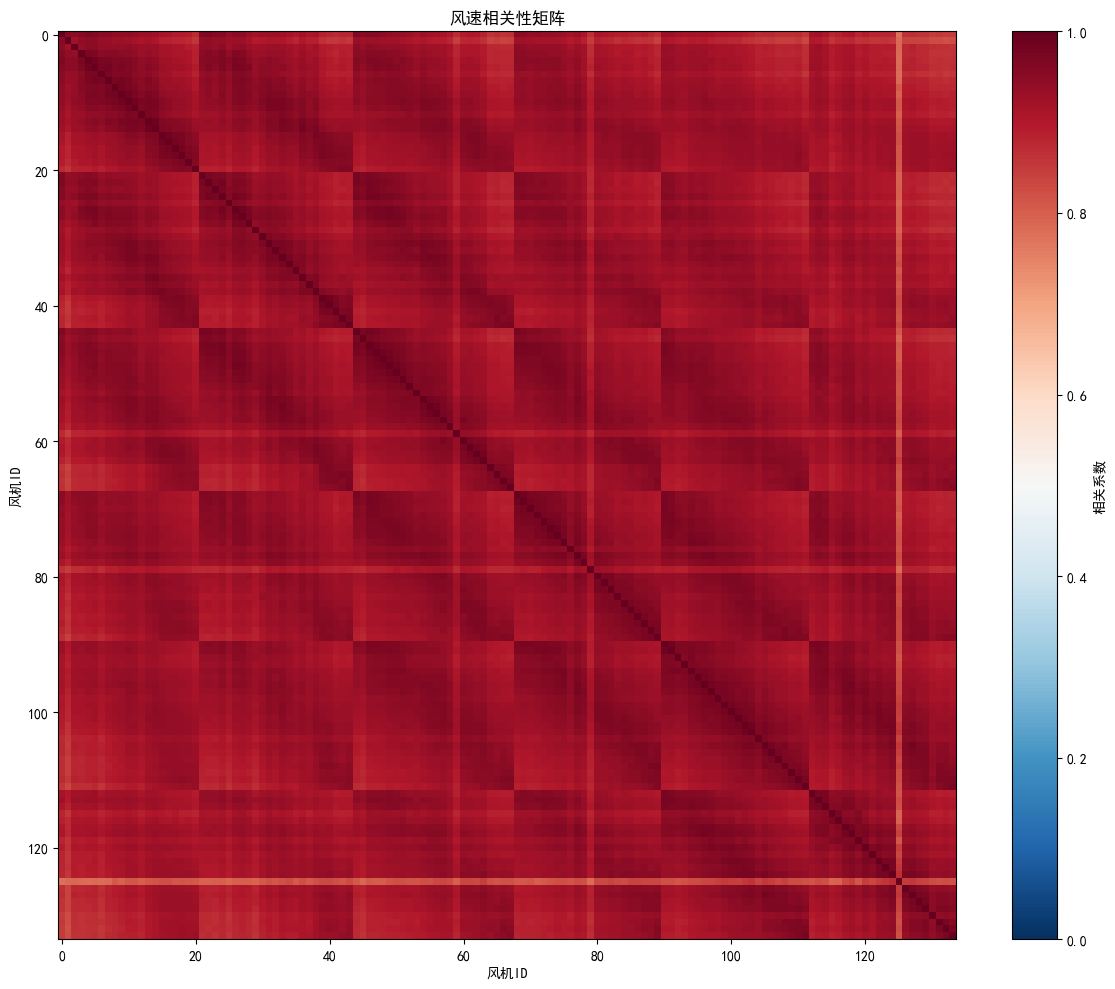

相关性矩阵图已保存为 wind_speed_correlation_matrix.png
正在计算相关性矩阵 (方法: pearson_diff)...
数据质量检查:
原始数据形状: (134, 24696)
差分数据形状: (134, 24695)

=== 相关性统计信息 ===
相关系数范围: [-0.028, 0.772]
平均相关系数: 0.291
相关系数标准差: 0.135
中位数相关系数: 0.249

相关性强度分布:
  强相关 (>0.7): 101/8911 (1.1%)
  中等相关 (0.4-0.7): 1583/8911 (17.8%)
  弱相关 (0.2-0.4): 4674/8911 (52.5%)
  很弱相关 (≤0.2): 2553/8911 (28.6%)

不同阈值下的连接统计:
  阈值 0.3: 3182/8911 (35.7%) 连接
  阈值 0.5: 843/8911 (9.5%) 连接
  阈值 0.7: 101/8911 (1.1%) 连接
  阈值 0.8: 0/8911 (0.0%) 连接
  阈值 0.9: 0/8911 (0.0%) 连接


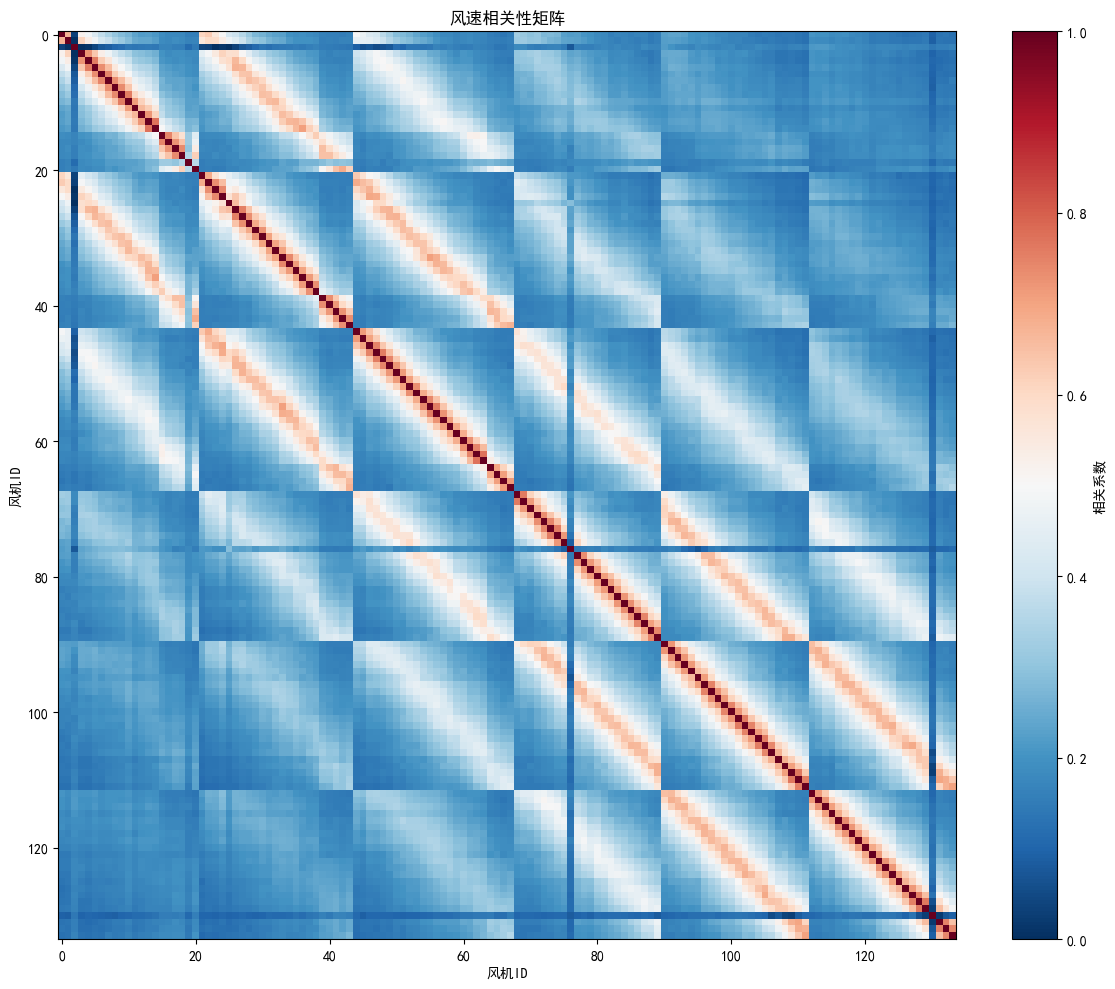

相关性矩阵图已保存为 wind_speed_diff_correlation_matrix.png
正在计算相关性矩阵 (方法: pearson_dir)...
数据质量检查:
原始数据形状: (134, 24696)
方向数据形状: 2

=== 相关性统计信息 ===
相关系数范围: [0.242, 0.752]
平均相关系数: 0.475
相关系数标准差: 0.082
中位数相关系数: 0.472

相关性强度分布:
  强相关 (>0.7): 43/8911 (0.5%)
  中等相关 (0.4-0.7): 7165/8911 (80.4%)
  弱相关 (0.2-0.4): 1703/8911 (19.1%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8830/8911 (99.1%) 连接
  阈值 0.5: 3335/8911 (37.4%) 连接
  阈值 0.7: 43/8911 (0.5%) 连接
  阈值 0.8: 0/8911 (0.0%) 连接
  阈值 0.9: 0/8911 (0.0%) 连接


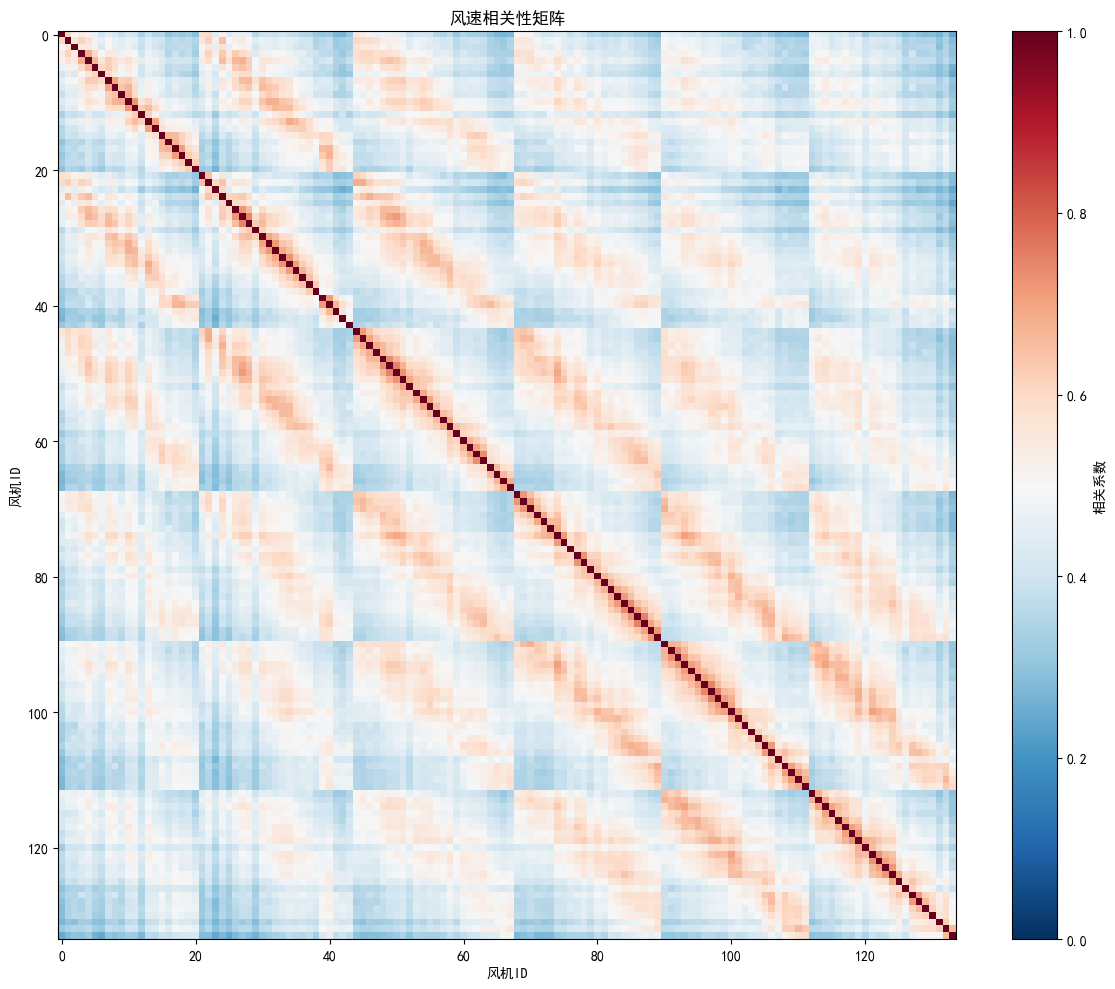

相关性矩阵图已保存为 wind_direction_correlation_matrix.png


In [17]:
print(wind_speed.shape, wind_direction.shape)
wind_corr = compute_correlation_matrix(wind_speed, method="pearson")
print_correlation_stats(wind_corr)
visualize_correlation_matrix(wind_corr, save_path="wind_speed_correlation_matrix.png")
np.savez("wind_speed_correlation_matrices.npz", original=wind_corr)
wind_diff_corr = compute_correlation_matrix(wind_speed, method="pearson_diff")
print_correlation_stats(wind_diff_corr)
visualize_correlation_matrix(wind_diff_corr, save_path="wind_speed_diff_correlation_matrix.png")
np.savez("wind_speed_diff_correlation_matrices.npz", original=wind_diff_corr)
wind_dir_corr = compute_correlation_matrix(wind_direction, method="pearson_dir")
print_correlation_stats(wind_dir_corr)
visualize_correlation_matrix(wind_dir_corr, save_path="wind_direction_correlation_matrix.png")
np.savez("wind_direction_correlation_matrices.npz", original=wind_dir_corr)
